In [4]:
# import time
import pandas as pd
from zhinst.toolkit import Session
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append(r"C:\Users\Ralph Group\Documents\Github\SagnacOperatingSys\MetaAnalysis")
from sagnalysis import get_noise_data


session = Session("localhost", hf2=True)
device = session.connect_device("DEV1004")

In [5]:
ogFreq = 3347620.0000000843;
# Modualtor 2 Freq = 3347620.0000000843
# Modulator1 Freq was 3.27320027 kHz

In [6]:
data = get_noise_data(device,  TcSet = 0.001, numSamples = 3, demod = 3)
data

,timestamp,x,y,frequency,phase,dio,trigger,auxin0,auxin1,Time,TcSet,TcReal
0,365569047461888,0.000206,0.000017,3347620.0,0.516097,526385151,3,-0.009155,-0.003662,0.023961,0.001,0.001002
0,365569055866880,0.000209,0.000017,3347620.0,2.889297,526385151,3,-0.008850,-0.002747,0.056962,0.001,0.001002
0,365569062404096,0.000220,0.000001,3347620.0,3.338856,526385151,3,-0.006714,-0.003052,0.089963,0.001,0.001002


# Bright noise vs Timeconstnt

## get data

In [7]:
Tcs =  np.arange(10e-3,2,20e-3);   #np.arange(10e-3,0.2,20e-3);  #Full range sweep
# Tcs = np.linspace(0.18,0.22,10); # to capture the 0.2 value with respect to time
# Tcs = np.linspace(0.24,0.26,10); # to capture the 0.25 value to see if ptCo is working
print(len(Tcs))
print(Tcs)


100
[0.01 0.03 0.05 0.07 0.09 0.11 0.13 0.15 0.17 0.19 0.21 0.23 0.25 0.27
 0.29 0.31 0.33 0.35 0.37 0.39 0.41 0.43 0.45 0.47 0.49 0.51 0.53 0.55
 0.57 0.59 0.61 0.63 0.65 0.67 0.69 0.71 0.73 0.75 0.77 0.79 0.81 0.83
 0.85 0.87 0.89 0.91 0.93 0.95 0.97 0.99 1.01 1.03 1.05 1.07 1.09 1.11
 1.13 1.15 1.17 1.19 1.21 1.23 1.25 1.27 1.29 1.31 1.33 1.35 1.37 1.39
 1.41 1.43 1.45 1.47 1.49 1.51 1.53 1.55 1.57 1.59 1.61 1.63 1.65 1.67
 1.69 1.71 1.73 1.75 1.77 1.79 1.81 1.83 1.85 1.87 1.89 1.91 1.93 1.95
 1.97 1.99]


In [8]:
results = dict()
for Tc in Tcs:
    print(f" Tc = {Tc}")
    data = get_noise_data(device,  TcSet = Tc , numSamples = 100, demod = 3, tmeasure = 60, FreqSet = ogFreq)
    results[Tc] = data

 Tc = 0.01
 Tc = 0.03
 Tc = 0.049999999999999996
 Tc = 0.06999999999999999
 Tc = 0.08999999999999998
 Tc = 0.10999999999999997
 Tc = 0.12999999999999998
 Tc = 0.15
 Tc = 0.16999999999999998
 Tc = 0.18999999999999997
 Tc = 0.20999999999999996
 Tc = 0.22999999999999998
 Tc = 0.24999999999999997
 Tc = 0.26999999999999996
 Tc = 0.29
 Tc = 0.30999999999999994
 Tc = 0.32999999999999996
 Tc = 0.35


KeyboardInterrupt: 

In [9]:
TcSet = [ data.TcSet.mean() for data in results.values()]
TcReal = [ data.TcReal.mean() for data in results.values()]
x1 = [ data.x.mean() for data in results.values()]
y1 = [ data.y.mean() for data in results.values()]
dx1 = [ data.x.std() for data in results.values()]
dy1 = [ data.y.std() for data in results.values()]
numMeas = [data.timestamp.count() for data in results.values()]

df = pd.DataFrame({'Freqs':ogFreq,'TcSet': TcSet, 'TcReal': TcReal, 'x1': x1, 'y1': y1, 'dx1': dx1, 'dy1': dy1, 'numMeas': numMeas})
df["xSensitivity"] = df.dx1 * np.sqrt(df.TcReal)
df["ySensitivity"] = df.dy1 * np.sqrt(df.TcReal)
df["xFracErr"] = df.dx1 /df.x1
df["yFracErr"] = df.dy1 /df.y1


In [10]:
df.to_csv('./PtCoNoise/PtPad.csv')

# df.to_csv('./NfoNoise/NFOgrphn_BrightNoise_FullTcSweep_keith0.0_0.csv')
# results_df.to_csv('./LafoNoise/raw_Lafo404_brightNoise.csv')

## plot

In [11]:
df0 = pd.read_csv('./LafoNoise/Lafo404_brightNoise.csv');
df1 = pd.read_csv('./LafoNoise/Lafo404_brightNoise_1.csv');
df2 = pd.read_csv('./LafoNoise/Lafo404_brightNoise_noEOM_0.csv');
df3 = pd.read_csv('./LafoNoise/Lafo404_brightNoise_noEOM_noheat_0.csv');
df4 = pd.read_csv('./LafoNoise/Lafo404_brightNoise_offOnEOM_noheat_tc0.2ish_0.csv');
df6 = pd.read_csv('./LafoNoise/Lafo404_brightNoise_EOM_noheat_tc0.2ish_4.csv');
df7 = pd.read_csv('./LafoNoise/Lafo404_brightNoise_EOM_noheat_tc0.2ish_6.csv');
df8 = pd.read_csv('./LafoNoise/Lafo404_brightNoise_EOM_noYesheat_tc0.2ish_0.csv');
df9 = pd.read_csv('./LafoNoise/Lafo404_brightNoise_EOM_noheat_tc0.2ish_10.csv');
df10 = pd.read_csv('./LafoNoise/Lafo404_brightNoise_EOM_noheat_tc0.2ish_3Fmod_0.csv');
df11 = pd.read_csv('./LafoNoise/Lafo404_brightNoise_EOM_noheat_tc0.2ish_1Fmod_1.csv');
df12 = pd.read_csv('./LafoNoise/Lafo404_brightNoise_EOM_noheat_tc0.2ish_1Fmod_styrofoamboxClosed_boxlight0ff_1.csv');
df13 = pd.read_csv('./LafoNoise/Lafo404_brightNoise_EOM_noheat_tc0.2ish_1Fmod_styrofoamboxClosed_boxlight0ff_roomlightoff_0.csv');
df14 = pd.read_csv('./LafoNoise/Lafo404_brightNoise_EOM_noheat_tc0.2ish_3Fmod_styrofoamboxClosed_boxlight0ff_roomlightoff_1.csv');
df15 = pd.read_csv('./LafoNoise/Lafo404_brightNoise_EOM_noheat_tc0.01-0.2_3Fmod_styrofoamboxClosed_boxlight0ff_roomlightoff_2.csv');
df16 = pd.read_csv('./LafoNoise/Lafo404_brightNoise_EOM_noheat_tc0.01-0.2_3Fmod_styrofoamboxClosedOpen_boxlight0ff_roomlightoff_3.csv');
df17 = pd.read_csv('./LafoNoise/Lafo404_brightNoise_EOM_noheat_tc0.2ish_3Fmod_styrofoamboxOpen_boxlight0ff_roomlightoff_5.csv');
df18 = pd.read_csv('./LafoNoise/Lafo404_brightNoise_EOM_noheat_tc0.2ish_3Fmod_styrofoamboxOpen_boxlight0ff_roomlightoff_walkInhalfwayTest_0.csv');
df19 = pd.read_csv('./LafoNoise/Lafo404_brightNoise_EOM_noheat_tc0.2ish_3Fmod_styrofoamboxClosed_boxlight0ff_roomlightoff_alwaysWavingHandsTappHalfway_0.csv');
df20 = pd.read_csv('./LafoNoise/Lafo404_brightNoise_reflectBeforeFiber_0.csv');
df21 = pd.read_csv('./LafoNoise/Lafo404_brightNoise_reflectBeforeFiber_roomlightsOut_0.csv');
df22 = pd.read_csv('./LafoNoise/Lafo404_brightNoise_reflectBeforeFiber_roomlightsOut_NDfilter_0.csv');
df23 = pd.read_csv('./LafoNoise/Lafo404_brightNoise_reflectBeforeFiber_roomlightsOut_NDfilter_FullTcSweep_1.csv');
df24 = pd.read_csv('./LafoNoise/Lafo404_darkNoise_FullTcSweep_1.csv');
df25 = pd.read_csv('./NfoNoise/NFOgrphn_BrightNoise_FullTcSweep_keith-10.0_0.csv');
df26 = pd.read_csv('./NfoNoise/NFOgrphn_BrightNoise_FullTcSweep_keith0.0_0.csv');

#2024/06/03 (skipped number to have a round number)
df30 = pd.read_csv('./PtCoNoise/PtCo_0Field_tc0.25.csv');
df31 = pd.read_csv('./LafoNoise/LafoPostlaserAngleTuning_0Field_tc0.25.csv')
df32 = pd.read_csv('./PtCoNoise/PtCo_0Field_tc0.25_1.csv');
df33 = pd.read_csv('./PtCoNoise/PtCo_0Field_tc0.25_2.csv');

# 2024/06/07
df35 = pd.read_csv('./BFONoise/PyBFO40-TW0306_0Field_tc0.25_3ogFreq.csv');
df36 = pd.read_csv('./BFONoise/PyBFO40-TW0306_0Field_tc0.25_1ogFreq.csv');

df37 = pd.read_csv('./PtCoNoise/PtCo_postBFO.csv');

#2024/06/24
df40 = pd.read_csv('./PtCoNoise/PtPad.csv');


<Axes: xlabel='TcSet'>

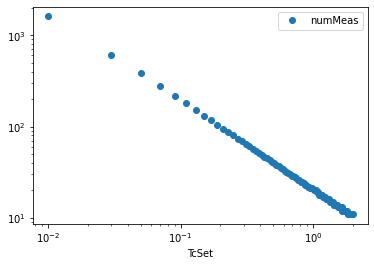

In [119]:
# sanity chec
df2.plot(x='TcSet', y='numMeas', logx=True, logy=True, style='o')

In [12]:
dontPlotAvg = True




def plotAvg(df24,  label="", column="xSensitivity",color='b'):

    # Calculate average for the specified column
    column_avg = df24[column].mean()

    # Add horizontal line for the average
    ax.axhline(y=column_avg, linestyle='--', label=f'{column} Avg: {column_avg:.2e}',color=color)


    if dontPlotAvg:
        print("returning and not plotting avg")
        return

    print(" plotting avg, not returning :() ")

    # Get the current x-axis limits
    xlim = ax.get_xlim()
    label_x_position = xlim[1] * 1.05  # Place the label just outside the plot on the right side

    # Add label for the average line on the right side of the y-axis
    ax.text(label_x_position, column_avg, f'{label} = {column_avg*1e6:.2f} uV', va='center', ha='left')

# Example usage:
# fig, ax = plt.subplots()
# plotAvg(df24, column="xSensitivity", label="xSensitivity")
# plotAvg(df24, column="ySensitivity", label="ySensitivity")
# plt.show()


 plotting avg, not returning :() 
 plotting avg, not returning :() 


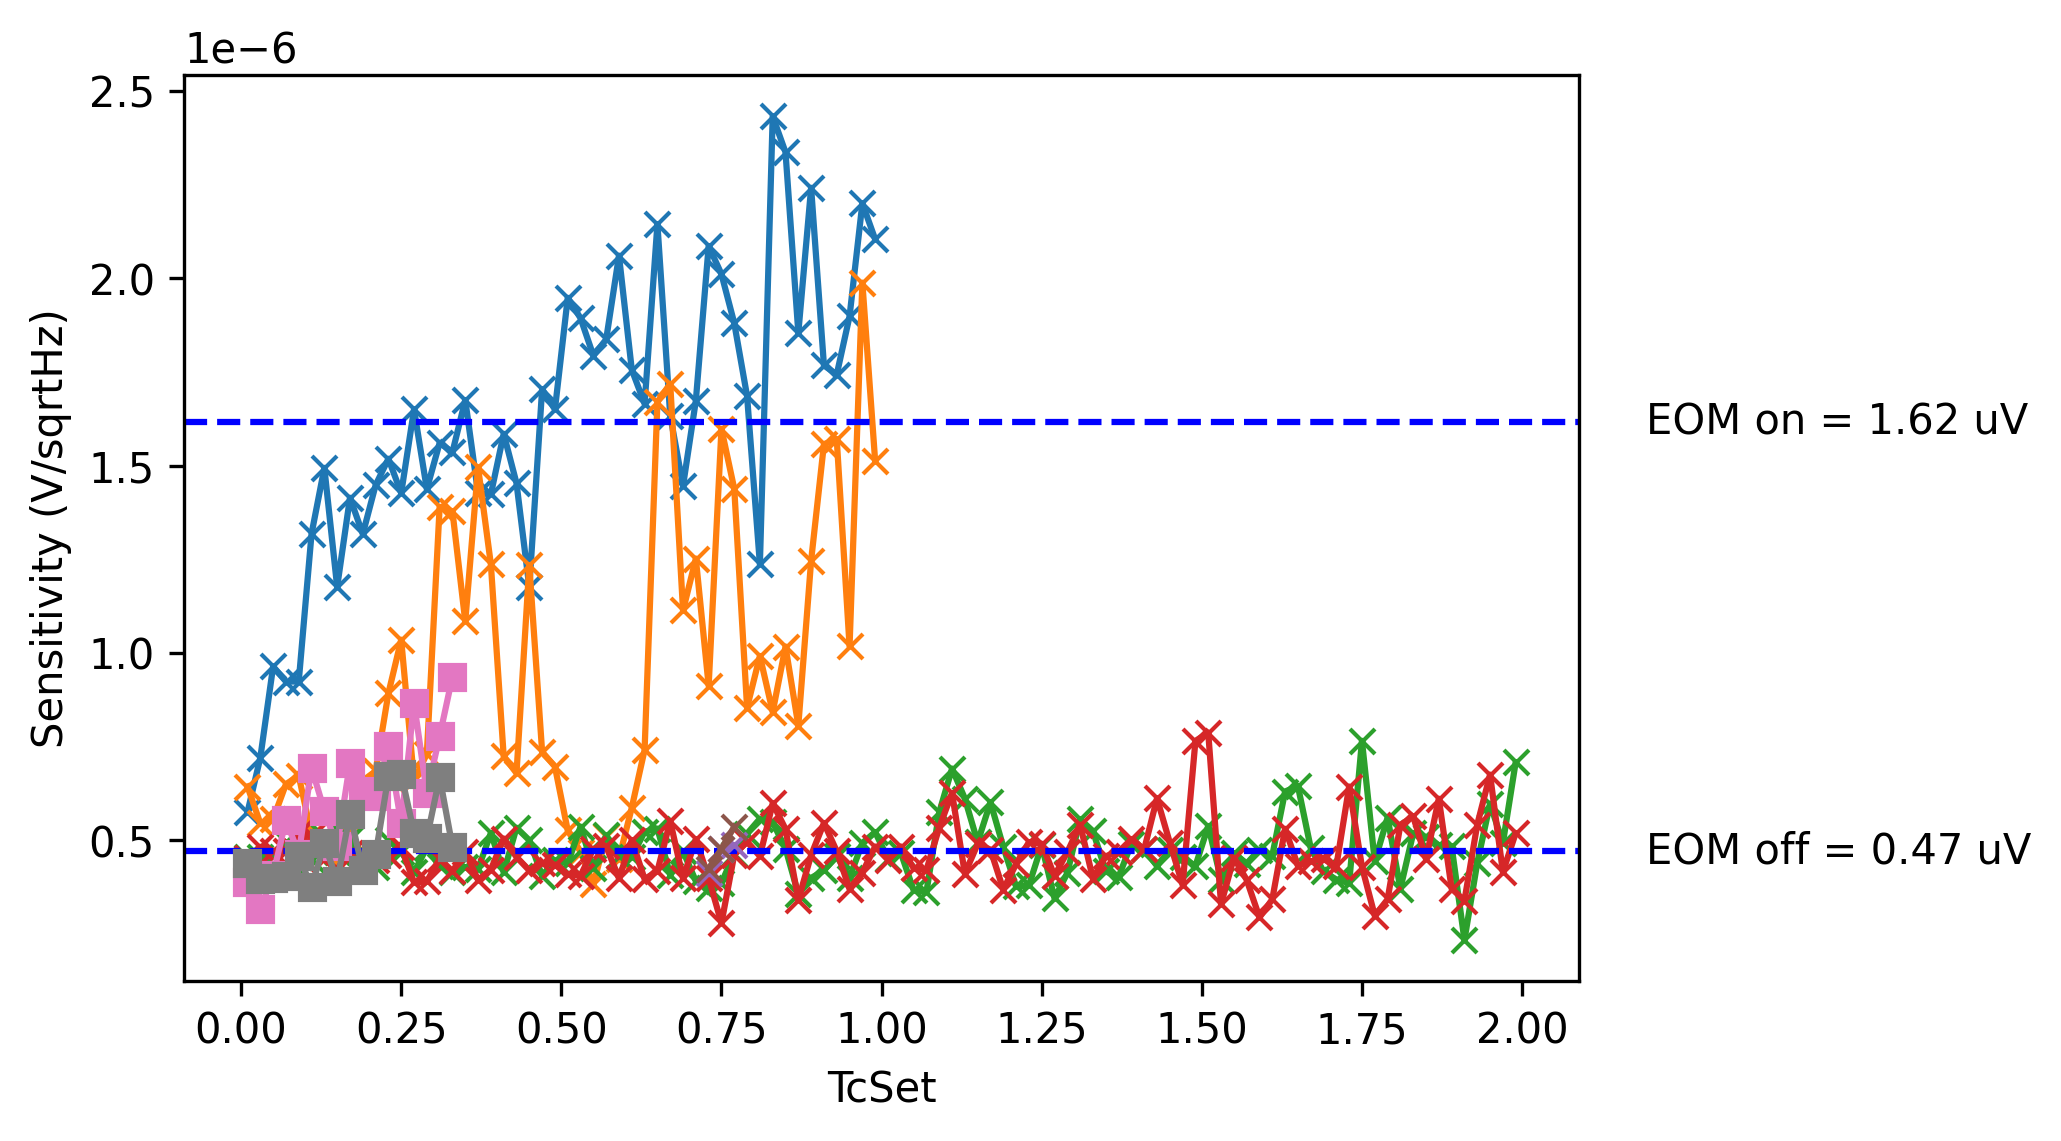

In [17]:
dontPlotAvg = False

fig, ax = plt.subplots(1, 1)
# fig, ax = plt.subplots(1, 1, figsize=(8, 30))

# ax.set_xlim(0.18,0.22)
# ax.set_xlim(0,0.2)

# 2024/06/03: set x limit to 0.24, 0.26 to see the 0.25 value
# ax.set_xlim(0.24,0.26)










# set dpi to 300
fig.set_dpi(300)



# Plotting both DataFrames on the same axes
# df0.plot(x='TcSet', y=['dx1', 'dy1'], marker='x', ax=ax) #initial quick pass


df1.plot(x='TcSet', y=['xSensitivity', 'ySensitivity'], marker='x', ax=ax) #EOM on, seems like drift at long time scales
df2.plot(x='TcSet', y=['xSensitivity', 'ySensitivity'], marker='x', ax=ax) # no EOM, full Tc sweep

plotAvg(df1,"EOM on")
plotAvg(df2,"EOM off")


df3.plot(x='TcSet', y=['xSensitivity', 'ySensitivity'], marker='x', ax=ax) #no EOM, at ~0.75 Tc to test repeatability
# df4.plot(x='TcSet', y=['xSensitivity', 'ySensitivity'], marker='x', ax=ax) #huge spike from turning on the eom sudenly





# ## 0.2 Tc repeatability test with EOM on
# df6.plot(x='TcSet', y=['xSensitivity'
#                     #    , 'ySensitivity'
#                        ], marker='x', ax=ax) #yes we still see greater noise now  EOM(~2uV) is on than with no EOM(0.5uV) 
# df7.plot(x='TcSet', y=['xSensitivity'
#                     #    , 'ySensitivity'
#                        ], marker='x', ax=ax) #yes we see greater than no EOM 0.5uV noise, it's repeatable






# ## Heat test
# df8.plot(x='TcSet', y=['xSensitivity'
#                      #    , 'ySensitivity'
#                          ], marker='x', ax=ax)  # turned on heat at 0.197 Tc set. Then turned off heat towards end. Moved the yeat source away in middle.
# df9.plot(x='TcSet', y=['xSensitivity'
#                      #    , 'ySensitivity'
#                          ], marker='x', ax=ax) # again no heat for repeatability




# ## 3Fmod test
# df10.plot(x='TcSet', y=['xSensitivity'
#                         #    , 'ySensitivity'
#                             ], marker='x', ax=ax) # 3Fmod, 0.2 Tc set, no heat, 
# df11.plot(x='TcSet', y=['xSensitivity'
#                         #    , 'ySensitivity'
#                             ], marker='x', ax=ax) # 1Fmod, 0.2 Tc set, no heat,
# df12.plot(x='TcSet', y=['xSensitivity'
#                         #    , 'ySensitivity'
#                             ], marker='x', ax=ax) # 1Fmod, 0.2 Tc set, no heat, styrofoam box closed, box light off

# df13.plot(x='TcSet', y=['xSensitivity'
#                         #    , 'ySensitivity'
#                             ], marker='x', ax=ax) # 1Fmod, 0.2 Tc set, no heat, styrofoam box closed, box light off, room light off
# df14.plot(x='TcSet', y=['xSensitivity'
#                         #    , 'ySensitivity'
#                             ], marker='x', ax=ax) # 3Fmod, 0.2 Tc set, no heat, styrofoam box closed, box light off, room light off

# df15.plot(x='TcSet', y=['xSensitivity'
#                         #    , 'ySensitivity'
#                             ], marker='x', ax=ax) # 3Fmod, testing if the initial transient is still there



# ## more thermal tests
# df16.plot(x='TcSet', y=['xSensitivity'
#                         #    , 'ySensitivity'
#                             ], marker='x', ax=ax) # 3Fmod, styrofoam box opened on 5th data point

# df17.plot(x='TcSet', y=['xSensitivity'
#                         #    , 'ySensitivity'
#                             ], marker='x', ax=ax) # 3Fmod, styrofoam box opened continously to see if it's thermal drift is repeatable

# df18.plot(x='TcSet', y=['xSensitivity'
#                         #    , 'ySensitivity'
#                             ], marker='x', ax=ax) # 3Fmod, styrofoam box opened  walked in halfway through and tapped the box and waved arms to generate air currents


# df19.plot(x='TcSet', y=['xSensitivity'
#                         #    , 'ySensitivity'
#                             ], marker='x', ax=ax) # 3Fmod, styrofoam box closed, waved arms and tapped halfway through






############################################################################################################


# ## no fiber testing
# df20.plot(x='TcSet', y=['xSensitivity'
#                         #    , 'ySensitivity'
#                             ], marker='x', ax=ax) #room lights on, reflect before fiber
# df21.plot(x='TcSet', y=['xSensitivity'
#                         #    , 'ySensitivity'
#                             ], marker='x', ax=ax) #room lights off, reflect before fiber

# df22.plot(x='TcSet', y=['xSensitivity'
#                         #    , 'ySensitivity'
#                             ], marker='x', ax=ax) #room lights off, reflect before fiber, ND filter

# df23.plot(x='TcSet', y=['xSensitivity'
#                            , 'ySensitivity'
#                             ], marker='x', ax=ax) #room lights off, reflect before fiber, ND filter, full Tc sweep
# plotAvg(df23,"nofiber")

# df24.plot(x='TcSet', y=['xSensitivity'
#                             , 'ySensitivity'
#                              ], marker='x', ax=ax) #dark noise, full Tc sweep
# plotAvg(df24,"Dark")


# df25.plot(x='TcSet', y=['xSensitivity'
#                             , 'ySensitivity'
#                              ], marker='x', ax=ax) #NFO bright noise, full Tc sweep, keith -10
# plotAvg(df25,"NFO bright x","xSensitivity")
# plotAvg(df25,"NFO bright Y","ySensitivity")


# df26.plot(x='TcSet', y=['xSensitivity'
#                             , 'ySensitivity'
#                              ], marker='x', ax=ax) #NFO bright noise, shorter Tc sweep, keith 0



# df30.plot(x='TcSet', y=['xSensitivity'
#                             , 'ySensitivity'
#                              ], marker='v', ax=ax) #PtCo bright noise, tc 0.25

# df31.plot(x='TcSet', y=['xSensitivity'
#                             , 'ySensitivity'
#                              ], marker='*', ax=ax) #Lafo bright noise,  tc 0.25

# df32.plot(x='TcSet', y=['xSensitivity'
#                             , 'ySensitivity'
#                              ], marker='o', ax=ax) #PtCo bright noise, tc 0.25







# df33.plot(x='TcSet', y=['xSensitivity'
#                             , 'ySensitivity'
#                              ], marker='x', ax=ax) #PtCo bright noise, tc 0.25 redo again
# plotAvg(df33,"PtCo bright noise","xSensitivity",color='r')
# plotAvg(df33,"PtCo bright noise","ySensitivity",color='r')

# # df35.plot(x='TcSet', y=['xSensitivity'
# #                             , 'ySensitivity'
# #                              ], marker='s', ax=ax) #BFONoise bright noise, tc 0.25 , 3ogFreq



# df36.plot(x='TcSet', y=['xSensitivity',
#                             'ySensitivity'
#                              ], marker='x', ax=ax) #BFONoise bright noise, tc 0.25, 1ogFreq
# plotAvg(df36,"BFONoise bright noise","xSensitivity",color='g')
# plotAvg(df36,"BFONoise bright noise","ySensitivity",color='g')



# df37.plot(x='TcSet', y=['xSensitivity',
#                             'ySensitivity'
#                              ], marker='x', ax=ax) #PtCo bright noise, tc 0.25, post BFO
# plotAvg(df37,"PtCo postBFO bright noise x","xSensitivity",color='b')
# plotAvg(df37,"PtCo postBFO bright noise y","ySensitivity",color='b')





df40.plot(x='TcSet', y=['xSensitivity',
                            'ySensitivity'
                             ], marker='s', ax=ax) #Pt only on the ptco device





# # put y on a log scale
# ax.set_yscale('log')
ax.set_ylabel('Sensitivity (V/sqrtHz)')




ax.get_legend().remove()

#save the figure
plt.savefig('./PtCoNoise/PtCo_0Field_tc0.25_2.jpg')


# Noise Frequency Spectrum

In [71]:
Freqs =  5* 10 ** np.linspace(-1, 7, 81); Freqs
# Freqs = [
# #      5.00000000e+01, 6.29462706e+01, 7.92446596e+01, 9.97631157e+01,
# #        1.25594322e+02, 1.58113883e+02, 1.99053585e+02, 2.50593617e+02,

#        1.25594322e+04, 1.58113883e+04, 1.99053585e+04, 2.50593617e+04,
#        3.15478672e+04, 3.97164117e+04, 5.00000000e+04, 6.29462706e+04,
#        ]

array([5.00000000e-01, 6.29462706e-01, 7.92446596e-01, 9.97631157e-01,
       1.25594322e+00, 1.58113883e+00, 1.99053585e+00, 2.50593617e+00,
       3.15478672e+00, 3.97164117e+00, 5.00000000e+00, 6.29462706e+00,
       7.92446596e+00, 9.97631157e+00, 1.25594322e+01, 1.58113883e+01,
       1.99053585e+01, 2.50593617e+01, 3.15478672e+01, 3.97164117e+01,
       5.00000000e+01, 6.29462706e+01, 7.92446596e+01, 9.97631157e+01,
       1.25594322e+02, 1.58113883e+02, 1.99053585e+02, 2.50593617e+02,
       3.15478672e+02, 3.97164117e+02, 5.00000000e+02, 6.29462706e+02,
       7.92446596e+02, 9.97631157e+02, 1.25594322e+03, 1.58113883e+03,
       1.99053585e+03, 2.50593617e+03, 3.15478672e+03, 3.97164117e+03,
       5.00000000e+03, 6.29462706e+03, 7.92446596e+03, 9.97631157e+03,
       1.25594322e+04, 1.58113883e+04, 1.99053585e+04, 2.50593617e+04,
       3.15478672e+04, 3.97164117e+04, 5.00000000e+04, 6.29462706e+04,
       7.92446596e+04, 9.97631157e+04, 1.25594322e+05, 1.58113883e+05,
      

In [72]:
results = dict()
for Freq in Freqs:
    print(Freq)
    data = get_noise_data(device,  TcSet = 0.01, numSamples = 100000000000000, demod = 3, tmeasure = 10, FreqSet = Freq)
    results[Freq] = data




0.5
0.6294627058970836
0.7924465962305567
0.9976311574844399
1.25594321575479
1.5811388300841898
1.9905358527674866
2.505936168136362
3.1547867224009667
3.9716411736214075
5.0
6.294627058970837
7.92446596230557
9.976311574844399
12.559432157547905
15.811388300841898
19.905358527674867
25.059361681363622
31.547867224009668
39.716411736214084
50.0
62.94627058970838
79.24465962305571
99.76311574844404
125.5943215754791
158.11388300841895
199.05358527674866
250.59361681363626
315.47867224009684
397.16411736214104
500.0
629.4627058970838
792.4465962305571
997.6311574844403
1255.9432157547913
1581.1388300841897
1990.5358527674866
2505.9361681363625
3154.7867224009683
3971.641173621411
5000.0
6294.627058970844
7924.46596230557
9976.311574844394
12559.43215754791
15811.388300841898
19905.358527674885
25059.361681363625
31547.867224009715
39716.41173621411
50000.0
62946.27058970844
79244.6596230557
99763.11574844414
125594.32157547912
158113.88300841895
199053.58527674887
250593.61681363627
315

In [73]:
# for Freq , data in results.items():
#     print(Freq), data.x.std())

# %matplotlib

TcSet = [ data.TcSet.mean() for data in results.values()]
TcReal = [ data.TcReal.mean() for data in results.values()]
x1 = [ data.x.mean() for data in results.values()]
y1 = [ data.y.mean() for data in results.values()]
dx1 = [ data.x.std() for data in results.values()]
dy1 = [ data.y.std() for data in results.values()]

df = pd.DataFrame({'Freqs':Freqs,'TcSet': TcSet, 'TcReal': TcReal, 'x1': x1, 'y1': y1, 'dx1': dx1, 'dy1': dy1})
df["xSensitivity"] = df.dx1 * np.sqrt(df.TcReal)
df["ySensitivity"] = df.dy1 * np.sqrt(df.TcReal)


In [74]:
# df.to_csv('darkNoise_OscFreqSweep_scantime10s_Rerun_1mod60Hz_tc10ms.csv')
# results_df.to_csv('darkNoise_OscFreqSweep_scantime1000s_rawdata.csv')

In [75]:
df0 = pd.read_csv('darkNoise_OscFreqSweep_scantime1000s.csv');
df1 = pd.read_csv('darkNoise_OscFreqSweep_scantime1000s_subsetRerun.csv');
df2 = pd.read_csv('darkNoise_OscFreqSweep_scantime1000s_subsetRerun2.csv');
df3 = pd.read_csv('darkNoise_OscFreqSweep_scantime1000s_subsubsetRerun1.csv');
df4 = pd.read_csv('darkNoise_OscFreqSweep_scantime1000s_subsubsetRerun_1mod3Hz.csv');
df5 = pd.read_csv('darkNoise_OscFreqSweep_scantime1000s_subsubsetRerun_1mod60Hz_tc10ms.csv');
df6 = pd.read_csv('50ohmNoise_OscFreqSweep_scantime10s_Rerun_1mod60Hz_tc10ms.csv');


<Axes: xlabel='Freqs'>

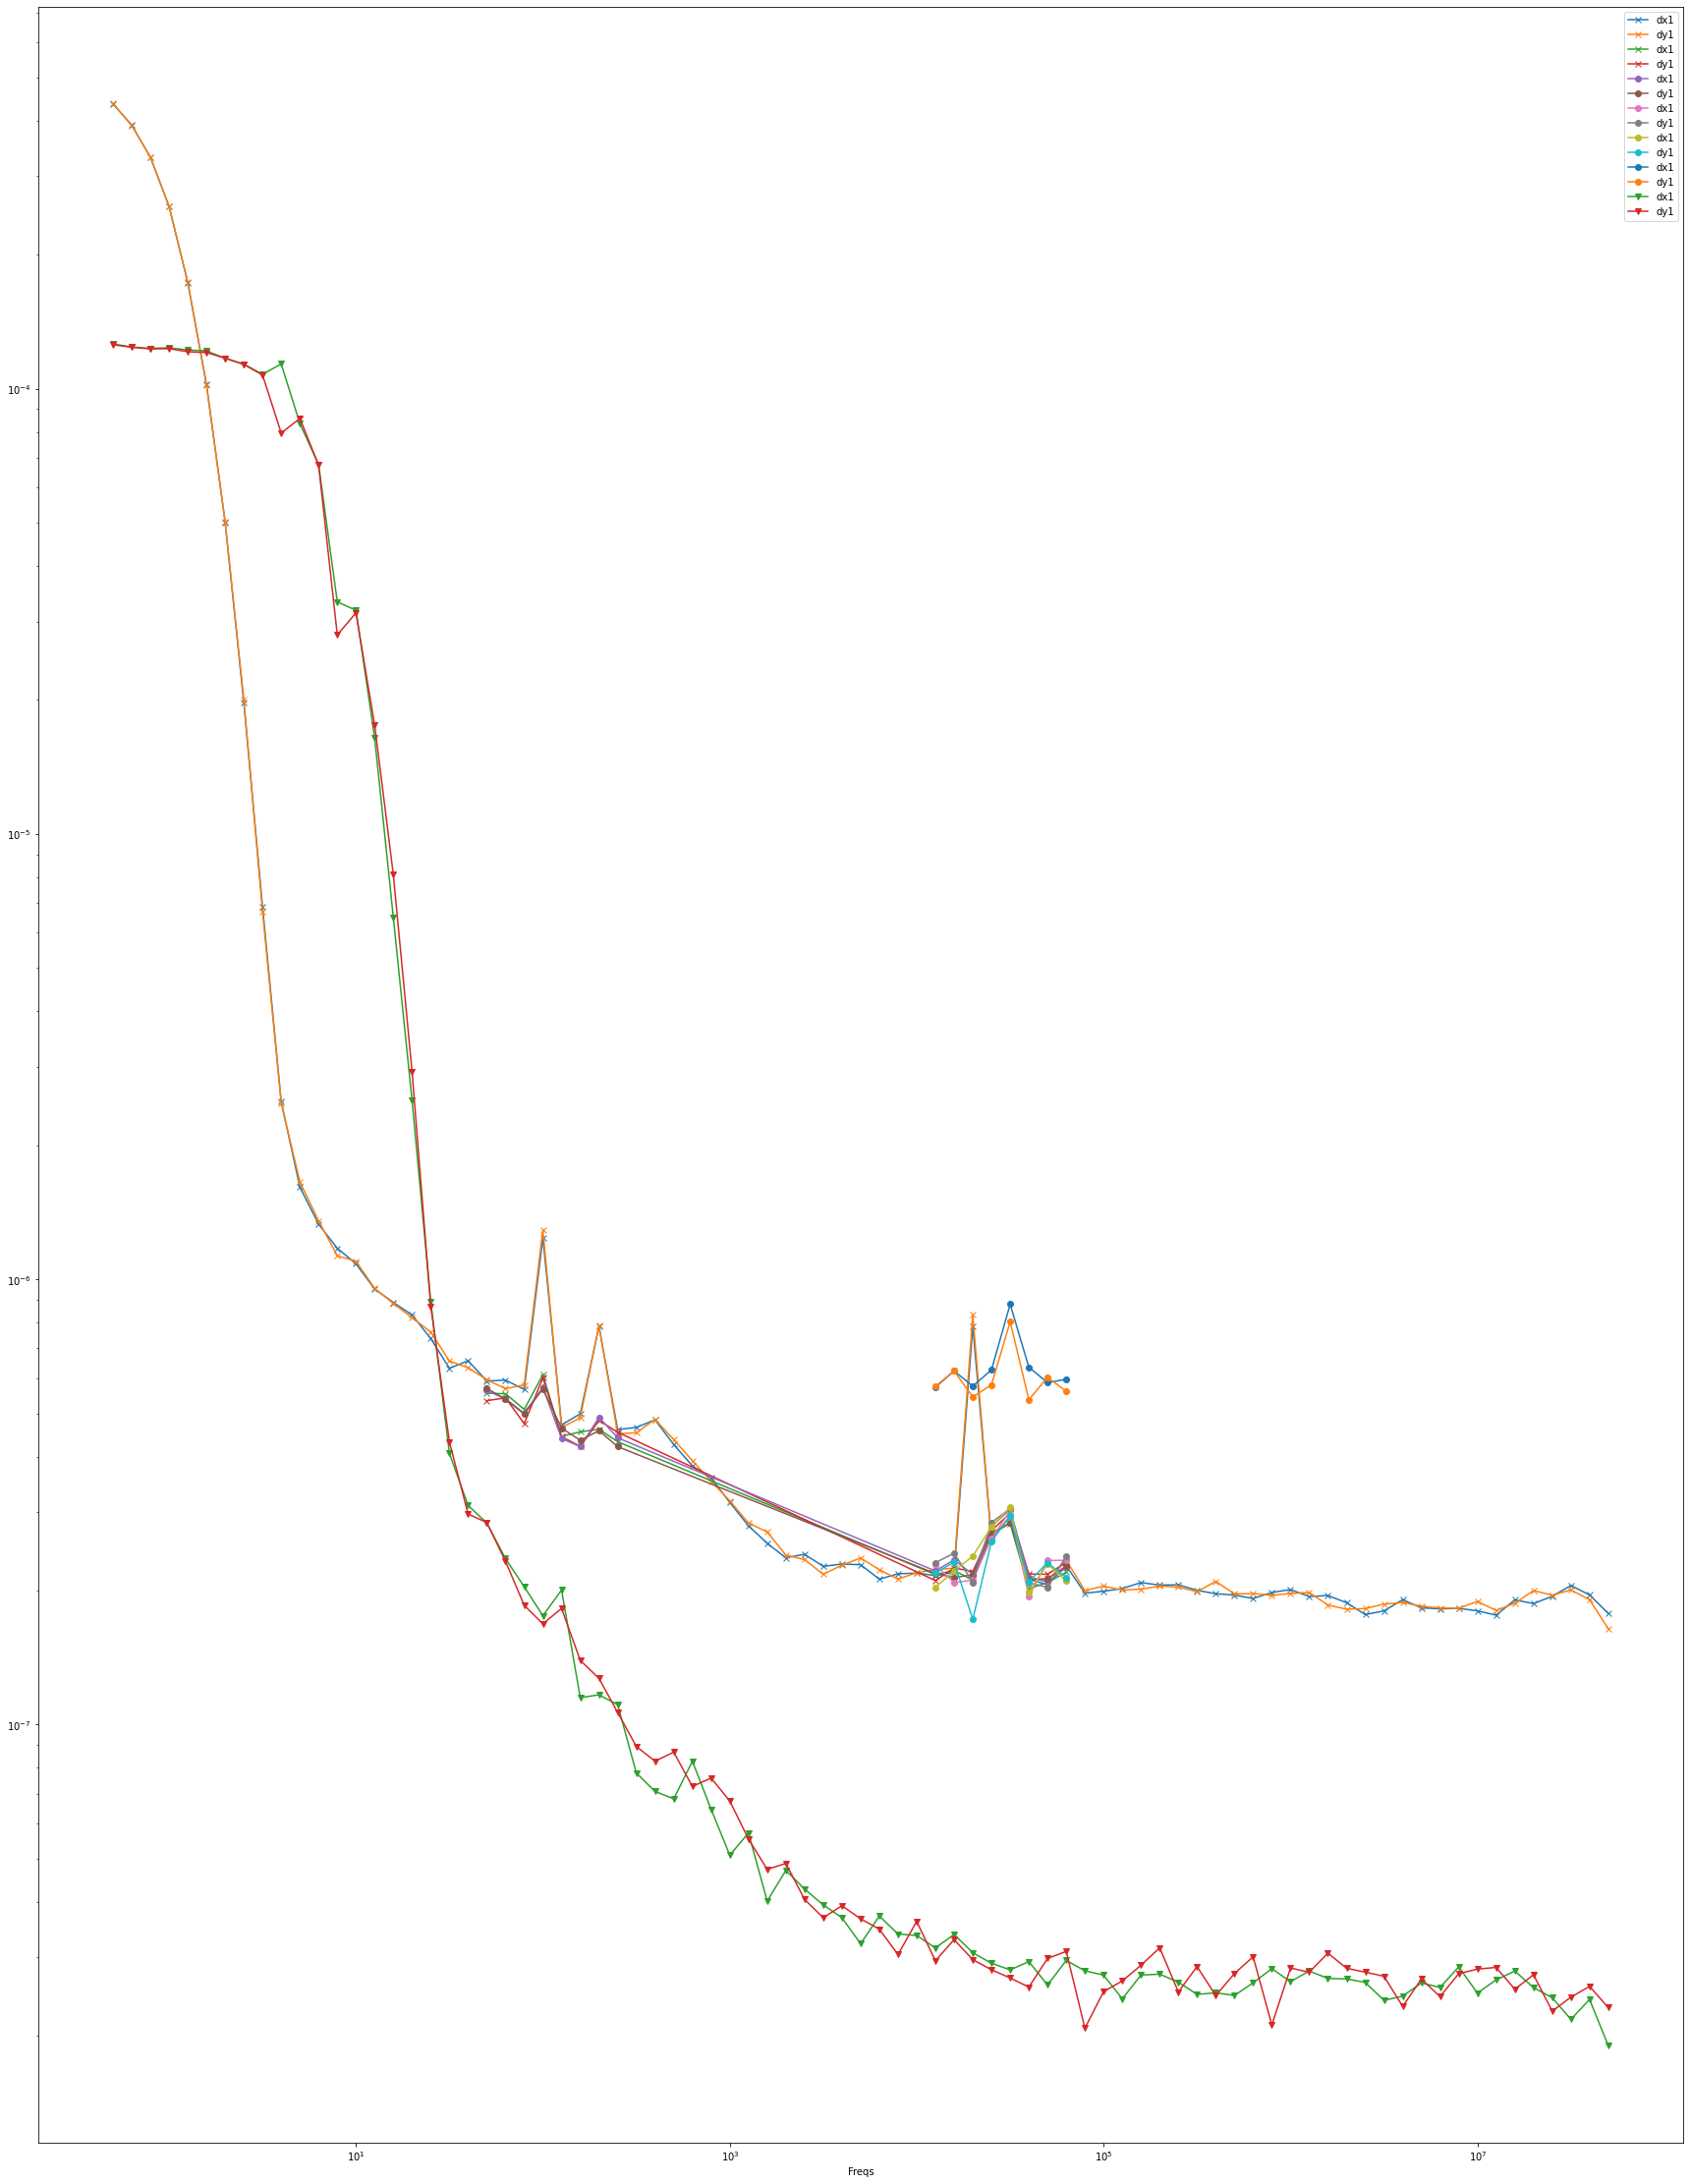

In [81]:
fig, ax = plt.subplots(1, 1, figsize=(30, 40))

#set dpi to 300
# fig.set_dpi(300)



# Plotting both DataFrames on the same axes
df0.plot(x='Freqs', y=['dx1', 'dy1'], logy=True, logx=True, marker='x', ax=ax)
df1.plot(x='Freqs', y=['dx1', 'dy1'], logy=True, logx=True, marker='x', ax=ax)
df2.plot(x='Freqs', y=['dx1', 'dy1'], logy=True, logx=True, marker='o', ax=ax)
df3.plot(x='Freqs', y=['dx1', 'dy1'], logy=True, logx=True, marker='o', ax=ax)
df4.plot(x='Freqs', y=['dx1', 'dy1'], logy=True, logx=True, marker='o', ax=ax)
df5.plot(x='Freqs', y=['dx1', 'dy1'], logy=True, logx=True, marker='o', ax=ax)
df6.plot(x='Freqs', y=['dx1', 'dy1'], logy=True, logx=True, marker='v', ax=ax) #Electronics noise




<Axes: xlabel='Freqs'>

<Figure size 432x288 with 0 Axes>

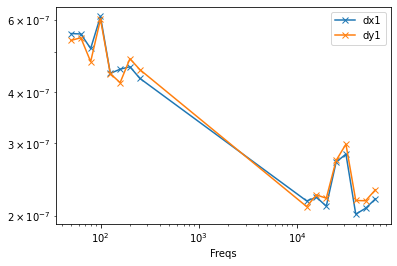

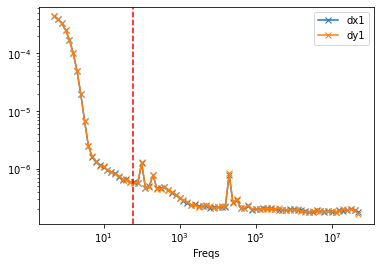

<Figure size 432x288 with 0 Axes>

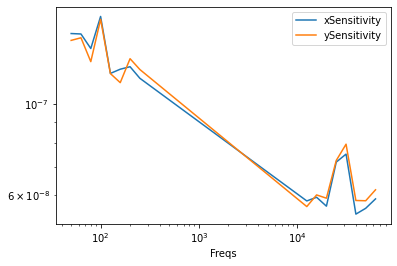

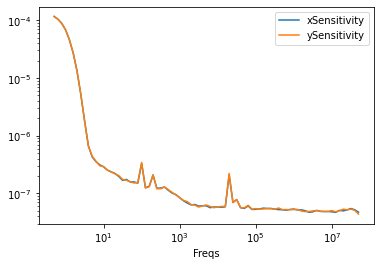

In [25]:
plt.figure()


df.plot(x='Freqs', y=['dx1','dy1'], logy=True,logx=True,marker='x')
df2.plot(x='Freqs', y=['dx1','dy1'], logy=True,logx=True,marker='x')

# vertical line at 60Hz
plt.axvline(x=60, color='r', linestyle='--')


plt.figure()
df.plot(x='Freqs', y=['xSensitivity','ySensitivity'], logy=True,logx=True)
df2.plot(x='Freqs', y=['xSensitivity','ySensitivity'], logy=True,logx=True)


In [21]:
# import pandas as pd

# # Sample DataFrames in a dictionary
# results = {
#     'experiment1': pd.DataFrame({
#         'A': [1, 2, 3],
#         'B': [4, 5, 6]
#     }),
#     'experiment2': pd.DataFrame({
#         'A': [7, 8, 9],
#         'B': [10, 11, 12]
#     })
# }

# Concatenating DataFrames including the dictionary keys as a new column
results_df = pd.concat(results.values(), keys=results.keys(), axis=0).reset_index()
# results_df.rename(columns={'level_0': 'Experiment'}, inplace=True)

# Show the DataFrame
results_df.level_0.unique()

# Uncomment the below line when finalizing the code
# results_df


array([5.00000000e-01, 6.29462706e-01, 7.92446596e-01, 9.97631157e-01,
       1.25594322e+00, 1.58113883e+00, 1.99053585e+00, 2.50593617e+00,
       3.15478672e+00, 3.97164117e+00, 5.00000000e+00, 6.29462706e+00,
       7.92446596e+00, 9.97631157e+00, 1.25594322e+01, 1.58113883e+01,
       1.99053585e+01, 2.50593617e+01, 3.15478672e+01, 3.97164117e+01,
       5.00000000e+01, 6.29462706e+01, 7.92446596e+01, 9.97631157e+01,
       1.25594322e+02, 1.58113883e+02, 1.99053585e+02, 2.50593617e+02,
       3.15478672e+02, 3.97164117e+02, 5.00000000e+02, 6.29462706e+02,
       7.92446596e+02, 9.97631157e+02, 1.25594322e+03, 1.58113883e+03,
       1.99053585e+03, 2.50593617e+03, 3.15478672e+03, 3.97164117e+03,
       5.00000000e+03, 6.29462706e+03, 7.92446596e+03, 9.97631157e+03,
       1.25594322e+04, 1.58113883e+04, 1.99053585e+04, 2.50593617e+04,
       3.15478672e+04, 3.97164117e+04, 5.00000000e+04, 6.29462706e+04,
       7.92446596e+04, 9.97631157e+04, 1.25594322e+05, 1.58113883e+05,
      